# Initialisation of the environment

## Import des librairies

In [1]:
# Librairies de base

import os          # Gestion des chemins et fichiers
import io          # Manipulation de flux mémoire
import numpy as np # Calcul numérique
import pandas as pd # Manipulation de données tabulaires
import matplotlib.pyplot as plt

#  Traitement d’images

from PIL import Image              # Ouverture et manipulation d’images
from tensorflow.keras.preprocessing.image import img_to_array  # Conversion image → tableau


#  TensorFlow / Keras

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,        # Modèle pré-entraîné
    preprocess_input    # Prétraitement des images pour MobileNetV2
)

#  PySpark – SQL & UDF

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, pandas_udf, PandasUDFType,
    element_at, split
)

#  PySpark – MLlib
from pyspark.ml import Pipeline
from pyspark.ml.feature import PCA, StandardScaler
from pyspark.ml.functions import array_to_vector


2026-04-03 13:57:50.331723: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-03 13:57:51.047243: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-03 13:57:51.075607: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 13:57:54.377973: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Création de la SparkSession

In [ ]:
print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/03 13:58:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
sc = spark.sparkContext

### Définition des PATH pour charger les images

In [ ]:
PATH = 's3://p9-fruits-project'
PATH_Data    = PATH + '/data/Test'
PATH_Result  = PATH + '/data/Results'
PATH_Pipeline = PATH + '/data/Pipeline'

print('PATH:         ' + PATH)
print('PATH_Data:    ' + PATH_Data)
print('PATH_Result:  ' + PATH_Result)
print('PATH_Pipeline:' + PATH_Pipeline)

PATH:         /opt/spark-notebooks
PATH_Data:    /opt/spark-notebooks/data/Test1
PATH_Result:  /opt/spark-notebooks/data/Results
PATH_Pipeline:/opt/spark-notebooks/data/Pipeline


## Initialisation du model

In [5]:
model = MobileNetV2(weights='imagenet',
                    include_top=True,
                    input_shape=(224, 224, 3))

for layer in model.layers:
    layer.trainable = False

14536120/14536120 [==============================] - 2s 0us/step


In [6]:
new_model = Model(inputs=model.input,
                  outputs=model.layers[-2].output)

new_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

In [7]:
brodcast_weights = sc.broadcast(new_model.get_weights())

## Functions to load, preprocess and generate feature from images

In [8]:
def preprocess(content):
    """
    Preprocesses raw image bytes for prediction.
    """
    img = Image.open(io.BytesIO(content)).resize([224, 224])
    arr = img_to_array(img)
    return preprocess_input(arr)


def featurize_series(model, content_series):
    """
    Featurize a pd.Series of raw images using the input model.
    :return: a pd.Series of image features
    """
    input = np.stack(content_series.map(preprocess))
    
    preds = model.predict(input)
    # For some layers, output features will be multi-dimensional tensors.
    # We flatten the feature tensors to vectors for easier storage in Spark DataFrames.
    output = [p.flatten() for p in preds]
    return pd.Series(output)


def model_fn():
    """
    Returns a MobileNetV2 model with top layer removed 
    and broadcasted pretrained weights.
    """
    model = MobileNetV2(weights='imagenet',
                        include_top=True,
                        input_shape=(224, 224, 3))
    for layer in model.layers:
        layer.trainable = False
    new_model = Model(inputs=model.input,
                      outputs=model.layers[-2].output)
    new_model.set_weights(brodcast_weights.value)
    return new_model


@pandas_udf('array<float>', PandasUDFType.SCALAR_ITER)
def featurize_udf(content_series_iter):
    '''
    This method is a Scalar Iterator pandas UDF wrapping our featurization function.
    The decorator specifies that this returns a Spark DataFrame column of type ArrayType(FloatType).

    :param content_series_iter: This argument is an iterator over batches of data, where each batch
                              is a pandas Series of image data.
    '''
    # With Scalar Iterator pandas UDFs, we can load the model once and then re-use it
    # for multiple data batches.  This amortizes the overhead of loading big models.
    model = model_fn()
    for content_series in content_series_iter:
        yield featurize_series(model, content_series)

/usr/local/lib/python3.8/dist-packages/pyspark/sql/pandas/functions.py:407: UserWarning: In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(


# Feature extraction and PCA

## Loading image, preprocessing and feature extraction

In [9]:
images = spark.read.format("binaryFile") \
    .option("pathGlobFilter", "*.jpg") \
    .option("recursiveFileLookup", "true") \
    .load(PATH_Data)


images = (images
          .withColumn('label',
                      element_at(split(images['path'], '/'), -2)
                     )
         ) 
print(images.printSchema())
print(images.select('path', 'label').show(5, False))


features_df = (images
    .repartition(20)
    .select(col("path"),
            col("label"),
            featurize_udf("content").alias("features")
           )
    .withColumn("features", array_to_vector("features")).cache()
)

print(features_df.printSchema())

root
 |-- path: string (nullable = true)
 |-- modificationTime: timestamp (nullable = true)
 |-- length: long (nullable = true)
 |-- content: binary (nullable = true)
 |-- label: string (nullable = true)

None


+---------------------------------------------------+-----+
|path                                               |label|
+---------------------------------------------------+-----+
|file:/opt/spark-notebooks/data/Test1/image_0029.jpg|Test1|
|file:/opt/spark-notebooks/data/Test1/image_0197.jpg|Test1|
|file:/opt/spark-notebooks/data/Test1/image_0167.jpg|Test1|
|file:/opt/spark-notebooks/data/Test1/image_0241.jpg|Test1|
|file:/opt/spark-notebooks/data/Test1/image_0181.jpg|Test1|
+---------------------------------------------------+-----+
only showing top 5 rows

None
root
 |-- path: string (nullable = true)
 |-- label: string (nullable = true)
 |-- features: vector (nullable = true)

None


## PCA : Creation and fitting a pipeline

In [10]:
# Initialisation of the two stages of the pipeline
Scalerizer = StandardScaler(
    inputCol="features",
    outputCol="Scaled_features",
    withStd= True,
    withMean = True
)


In [11]:
print("Nombre d'images :", images.count())

[Stage 1:==============================================>           (8 + 2) / 10]

Nombre d'images : 300


In [12]:
PCA_model = PCA(k=200,inputCol="Scaled_features", outputCol="pca_features")


# Creation of the pipeline
pipeline = Pipeline(stages=[Scalerizer, PCA_model])


# fitting of the pipeline
pipeline_model = pipeline.fit(features_df)

# Explained variance of the 200 first components
print("Variance explained by the 200 first components: ",pipeline_model.stages[1].explainedVariance.sum())

26/04/03 13:59:48 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Variance explained by the 200 first components:  0.9752373236630186


In [13]:
features_df = pipeline_model.transform(features_df)

features_df.show(5)

26/04/03 14:00:00 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


+--------------------+-----+--------------------+--------------------+--------------------+
|                path|label|            features|     Scaled_features|        pca_features|
+--------------------+-----+--------------------+--------------------+--------------------+
|file:/opt/spark-n...|Test1|[1.32163357734680...|[2.12069320485261...|[-24.227063379285...|
|file:/opt/spark-n...|Test1|[1.71109664440155...|[3.00090705643876...|[4.15490025019215...|
|file:/opt/spark-n...|Test1|[0.97609281539916...|[1.33974684386895...|[6.76985558643045...|
|file:/opt/spark-n...|Test1|[0.0,0.0,0.0,0.0,...|[-0.8662913898598...|[6.59466104592020...|
|file:/opt/spark-n...|Test1|[0.34706372022628...|[-0.0819030363340...|[10.8127182842401...|
+--------------------+-----+--------------------+--------------------+--------------------+
only showing top 5 rows



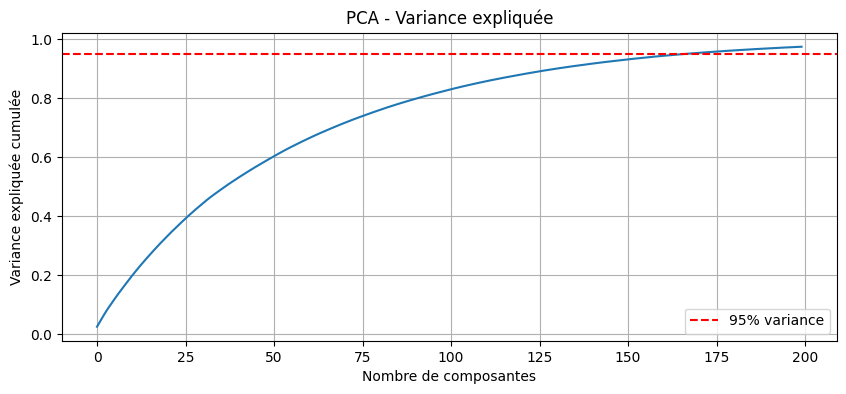

Variance expliquée par 200 composantes : 97.52%


In [14]:
explained_var = pipeline_model.stages[1].explainedVariance.toArray()
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(10, 4))
plt.plot(cumulative_var)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('PCA - Variance expliquée')
plt.legend()
plt.grid(True)
plt.show()

print(f"Variance expliquée par {len(explained_var)} composantes : {cumulative_var[-1]:.2%}")

## Exporting the data and the pipeline

In [15]:
# Export the dataframe (parquet format)
features_df.write.mode("overwrite").parquet(PATH_Result)


# Export the fitted pipeline (scaling+PCA)
pipeline_model.write().overwrite().save(PATH_Pipeline)

26/04/03 14:00:01 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/04/03 14:00:08 WARN TaskSetManager: Stage 34 contains a task of very large size (2050 KiB). The maximum recommended task size is 1000 KiB.


# Chargement des données

In [16]:
df = spark.read.parquet(PATH_Result)

In [18]:
df.show()

[Stage 39:>                                                         (0 + 1) / 1]

+--------------------+-----+--------------------+--------------------+--------------------+
|                path|label|            features|     Scaled_features|        pca_features|
+--------------------+-----+--------------------+--------------------+--------------------+
|file:/opt/spark-n...|Test1|[1.13182377815246...|[1.69170974390186...|[-19.738050891216...|
|file:/opt/spark-n...|Test1|[0.91064220666885...|[1.19182387691129...|[-19.945653002020...|
|file:/opt/spark-n...|Test1|[2.48254847526550...|[4.74444230996896...|[-6.0268750117487...|
|file:/opt/spark-n...|Test1|[0.31524094939231...|[-0.1538247307214...|[7.00602866014087...|
|file:/opt/spark-n...|Test1|[1.35743510723114...|[2.20160717379575...|[5.18650261558430...|
|file:/opt/spark-n...|Test1|[0.82653045654296...|[1.00172542135851...|[9.59389955260433...|
|file:/opt/spark-n...|Test1|[0.65000897645950...|[0.60277449374689...|[7.42995539777184...|
|file:/opt/spark-n...|Test1|[0.37867465615272...|[-0.0104601036973...|[7.2092614

In [20]:
df.head().features.size

1280

In [23]:
(df.count(), len(df.columns))

(300, 5)